In [2]:
print(tf.__version__)
print(tf.config.list_physical_devices())
print(tf.test.is_built_with_cuda())

2.19.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
True


In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers


In [3]:
num_classes = 25  # labels 0-24 (A-Z excluding J=9 and Z=25)
input_shape = (28, 28, 1)

# Load Sign Language MNIST from local CSV files
train_df = pd.read_csv('sign_mnist_train.csv')
test_df = pd.read_csv('sign_mnist_test.csv')

# Split labels and pixel data
y_train = train_df['label'].values
x_train = train_df.drop('label', axis=1).values
y_test = test_df['label'].values
x_test = test_df.drop('label', axis=1).values

# Reshape to 28x28x1 and scale to [0, 1]
x_train = x_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")


x_train shape: (27455, 28, 28, 1)
27455 train samples
7172 test samples


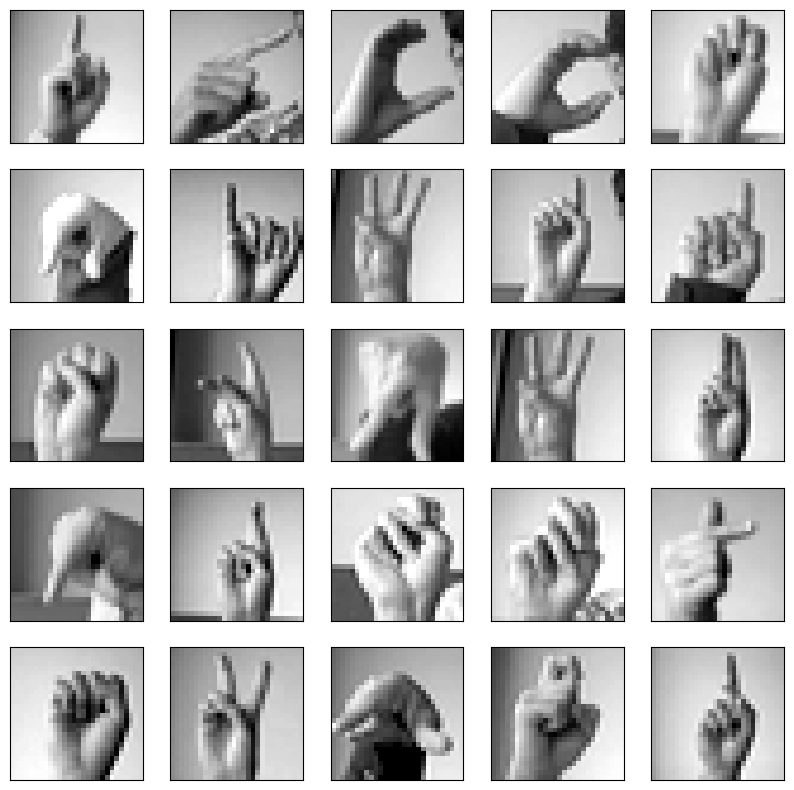

In [4]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.squeeze(x_train[i,:,:,:]), cmap='gray')
plt.show()


In [5]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test = tf.keras.utils.to_categorical(y_test, num_classes)

In [6]:

# # --- Original Simple Model ---
# model = tf.keras.Sequential(
#     [
#          tf.keras.Input(shape=input_shape),
#          layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
#          layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),
#          layers.MaxPooling2D(pool_size=(2, 2)),
#          layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
#          layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
#          layers.MaxPooling2D(pool_size=(2, 2)),
#          layers.Conv2D(128, kernel_size=(3, 3), activation="relu"),
#          layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding='same'),
#          layers.MaxPooling2D(pool_size=(2, 2)),
#          layers.Flatten(),
#          #layers.Dropout(0.5),
#          layers.Dense(128, activation="relu"),
#          layers.Dense(num_classes, activation="softmax"),
#      ]
#  )
# model.summary()

# --- VGG-Inspired Model ---
model = tf.keras.Sequential([
    tf.keras.Input(shape=input_shape),

    # Block 1
    layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Classifier head
    layers.Flatten(),
    layers.Dense(512, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax'),
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 7, 7, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,059,929 (11.67 MB)

 Trainable params: 3,056,089 (11.66 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [7]:
from keras.optimizers import Adam

batch_size = 64
epochs = 15

#Adm = Adam(lr=0.1)

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

In [8]:
history = model.fit(x_train, y_train, batch_size=128, epochs=10, validation_split=0.1)

Epoch 1/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 38s 104ms/step - accuracy: 0.6620 - loss: 1.4475 - val_accuracy: 0.0444 - val_loss: 9.8160
Epoch 2/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9620 - loss: 0.3693 - val_accuracy: 0.5568 - val_loss: 1.6513
Epoch 3/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9784 - loss: 0.3182 - val_accuracy: 0.9869 - val_loss: 0.2761
Epoch 4/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9979 - loss: 0.2473 - val_accuracy: 1.0000 - val_loss: 0.2307
Epoch 5/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9994 - loss: 0.2324 - val_accuracy: 1.0000 - val_loss: 0.2223
Epoch 6/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9992 - loss: 0.2237 - val_accuracy: 1.0000 - val_loss: 0.2134
Epoch 7/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.9994 - loss: 0.2128 - val_accuracy: 1.0000 - val_loss: 0.2038
Epoch 8/10
194/194 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.9981 - loss: 0.2088 - val_ac

In [9]:
score = model.evaluate(x_test, y_test, verbose=0)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Test loss: 0.2298881709575653
Test accuracy: 0.9875906109809875


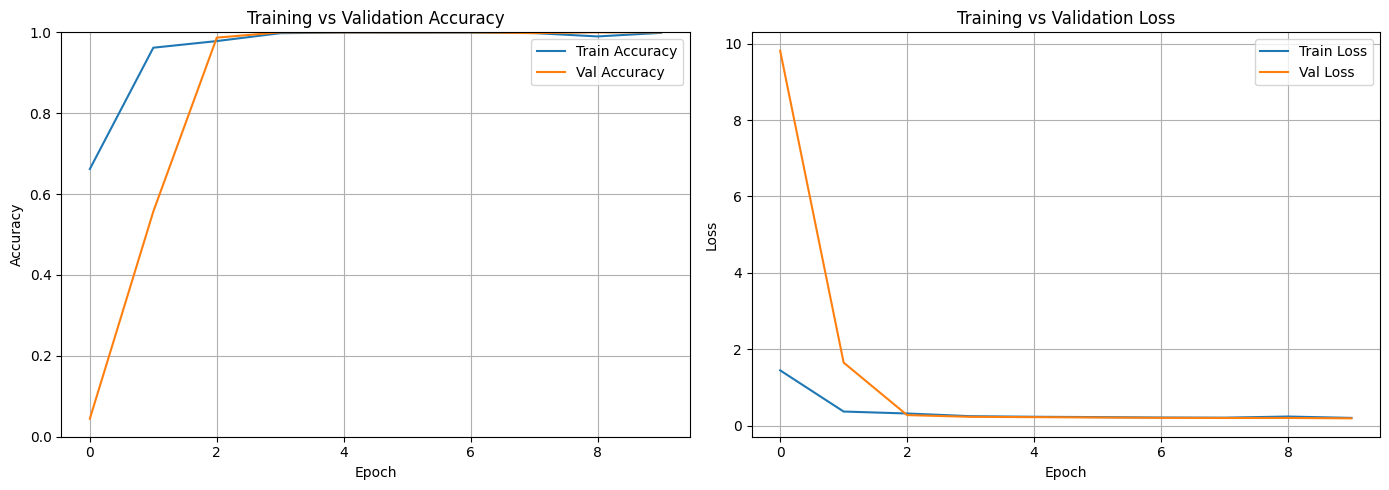

In [10]:
import time

# Training vs Validation Accuracy & Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1])
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [11]:
# Model Comparison Table (accuracy, loss, parameters, training time)
total_params = model.count_params()
trainable_params = sum(
    tf.keras.backend.count_params(w) for w in model.trainable_weights
)

num_epochs_run = len(history.history['accuracy'])
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

comparison_df = pd.DataFrame({
    'Metric': [
        'Train Accuracy', 'Validation Accuracy', 'Test Accuracy',
        'Train Loss', 'Validation Loss', 'Test Loss',
        'Total Parameters', 'Trainable Parameters',
        'Epochs Trained'
    ],
    'Value': [
        f'{final_train_acc:.4f}', f'{final_val_acc:.4f}', f'{test_acc:.4f}',
        f'{final_train_loss:.4f}', f'{final_val_loss:.4f}', f'{test_loss:.4f}',
        f'{total_params:,}', f'{trainable_params:,}',
        f'{num_epochs_run}'
    ]
})

print("=" * 50)
print("        Model Performance Summary")
print("=" * 50)
print(comparison_df.to_string(index=False))
print("=" * 50)

        Model Performance Summary
              Metric     Value
      Train Accuracy    0.9987
 Validation Accuracy    1.0000
       Test Accuracy    0.9876
          Train Loss    0.2027
     Validation Loss    0.1912
           Test Loss    0.2299
    Total Parameters 3,059,929
Trainable Parameters 3,056,089
      Epochs Trained        10


225/225 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


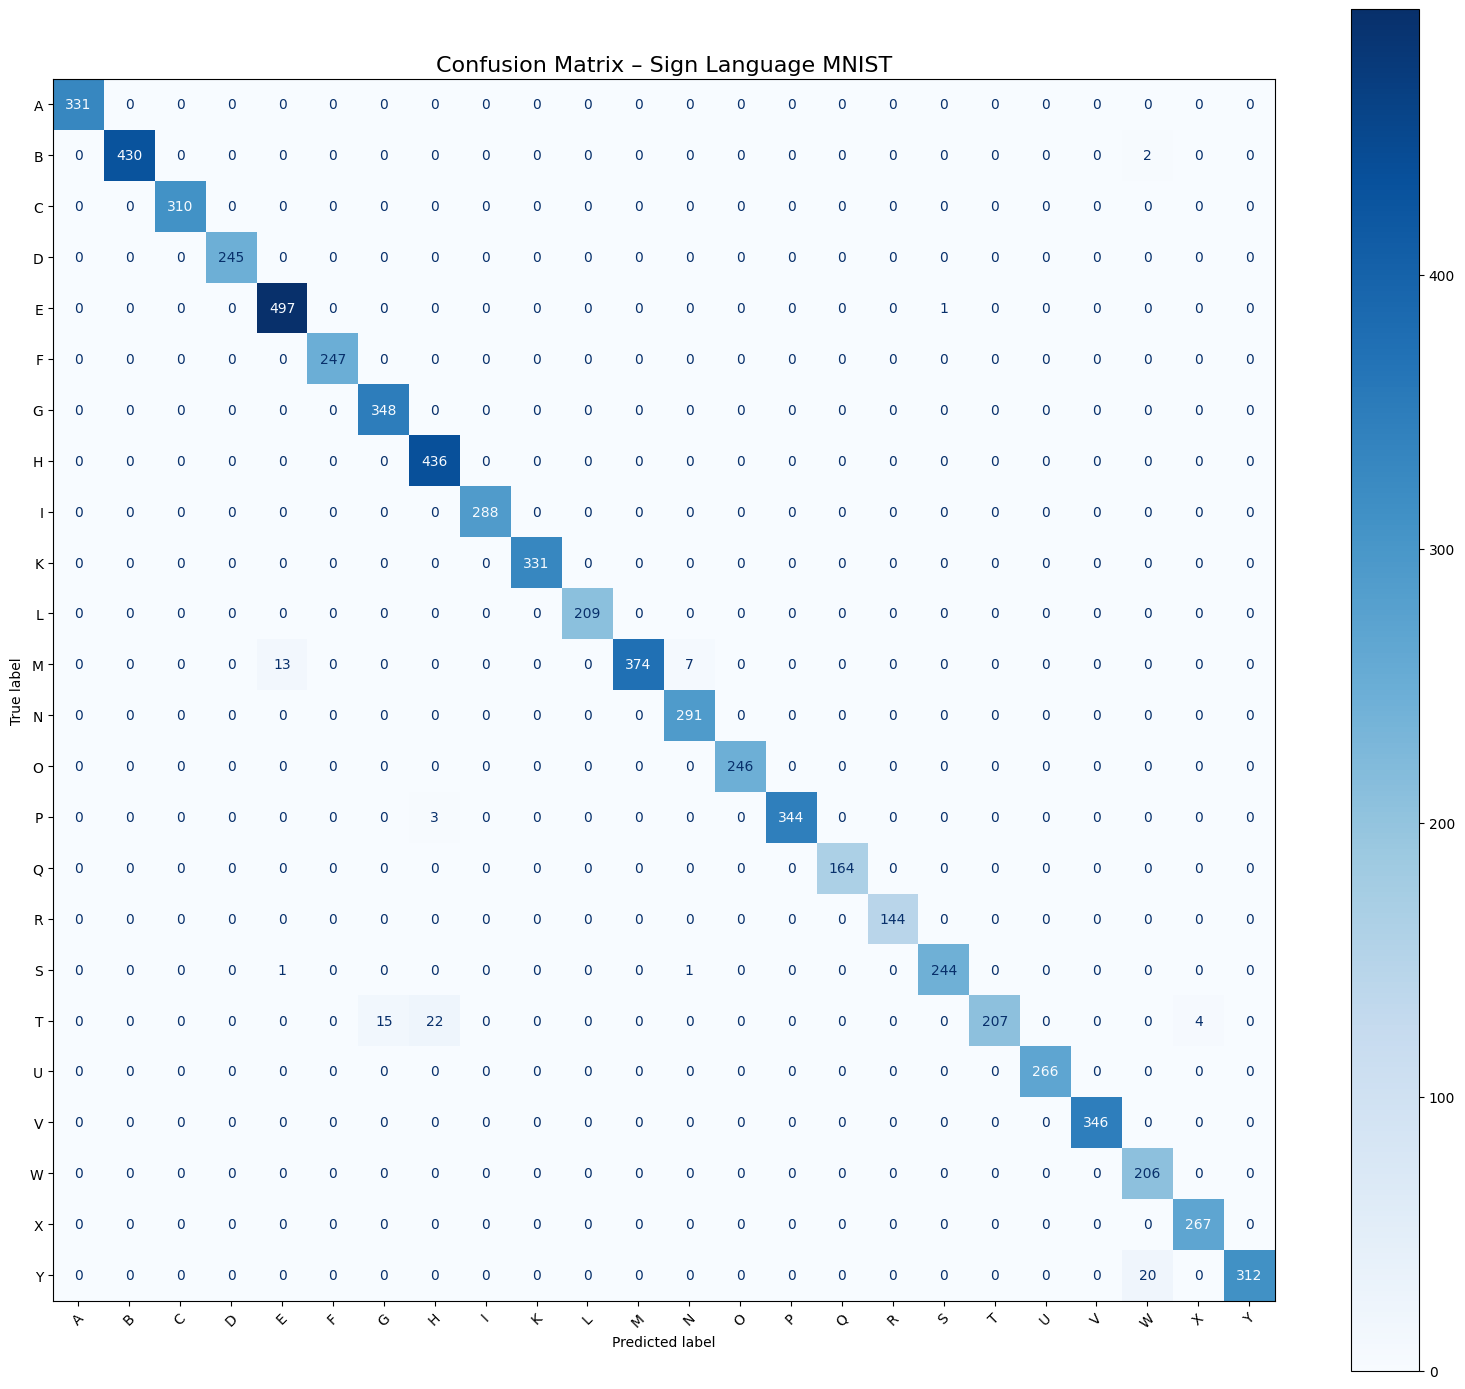


  Confusion Matrix Analysis

Top 5 hardest classes to classify (lowest accuracy):
  Letter 'T': accuracy = 83.47%, most confused with 'H' (22 times)
  Letter 'Y': accuracy = 93.98%, most confused with 'W' (20 times)
  Letter 'M': accuracy = 94.92%, most confused with 'E' (13 times)
  Letter 'P': accuracy = 99.14%, most confused with 'H' (3 times)
  Letter 'S': accuracy = 99.19%, most confused with 'E' (1 times)

Patterns in misclassification:
Classes with subtle finger-position differences are harder to distinguish.
Classes with higher sample counts tend to achieve better accuracy.


In [12]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Letter labels: A-Z excluding J(9) and Z(25)
label_names = [chr(i) for i in range(65, 91) if chr(i) not in ('J', 'Z')]  # A-I, K-Y

# 25-element lookup: index maps directly to letter
label_lookup = [chr(65 + i) for i in range(25)]   # index 9 = 'J' is unused

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(16, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap='Blues', ax=ax, values_format='d', xticks_rotation=45)
ax.set_title('Confusion Matrix – Sign Language MNIST', fontsize=16)
plt.tight_layout()
plt.show()

# Hardest-to-classify classes
print("\n" + "=" * 60)
print("  Confusion Matrix Analysis")
print("=" * 60)

# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
hardest_idx = np.argsort(per_class_acc)[:5]

print("\nTop 5 hardest classes to classify (lowest accuracy):")
for idx in hardest_idx:
    # Most confused with
    row = cm[idx].copy()
    row[idx] = 0  # exclude self
    confused_with_idx = np.argmax(row)
    print(f"  Letter '{label_names[idx]}': accuracy = {per_class_acc[idx]:.2%}, "
          f"most confused with '{label_names[confused_with_idx]}' ({row[confused_with_idx]} times)")

print("\nPatterns in misclassification:")
print("Classes with subtle finger-position differences are harder to distinguish.")
print("Classes with higher sample counts tend to achieve better accuracy.")

In [13]:
# Classification Report with Precision, Recall, F1-Score
from sklearn.metrics import classification_report

report = classification_report(y_true, y_pred, target_names=label_names, digits=4)
print("=" * 70)
print("       Classification Report – Precision, Recall, F1-Score")
print("=" * 70)
print(report)

# Show predicted vs true label for the first 20 test samples
print("=" * 70)
print("  Sample Predicted vs True Labels (first 20 test samples)")
print("=" * 70)
pred_vs_true = pd.DataFrame({
    'Sample #': range(1, 21),
    'True Label': [label_lookup[y_true[i]] for i in range(20)],
    'Predicted Label': [label_lookup[y_pred[i]] for i in range(20)],
    'Correct': ['✓' if y_true[i] == y_pred[i] else '✗' for i in range(20)]
})
print(pred_vs_true.to_string(index=False))

       Classification Report – Precision, Recall, F1-Score
              precision    recall  f1-score   support

           A     1.0000    1.0000    1.0000       331
           B     1.0000    0.9954    0.9977       432
           C     1.0000    1.0000    1.0000       310
           D     1.0000    1.0000    1.0000       245
           E     0.9726    0.9980    0.9851       498
           F     1.0000    1.0000    1.0000       247
           G     0.9587    1.0000    0.9789       348
           H     0.9458    1.0000    0.9721       436
           I     1.0000    1.0000    1.0000       288
           K     1.0000    1.0000    1.0000       331
           L     1.0000    1.0000    1.0000       209
           M     1.0000    0.9492    0.9740       394
           N     0.9732    1.0000    0.9864       291
           O     1.0000    1.0000    1.0000       246
           P     1.0000    0.9914    0.9957       347
           Q     1.0000    1.0000    1.0000       164
           R     1.000

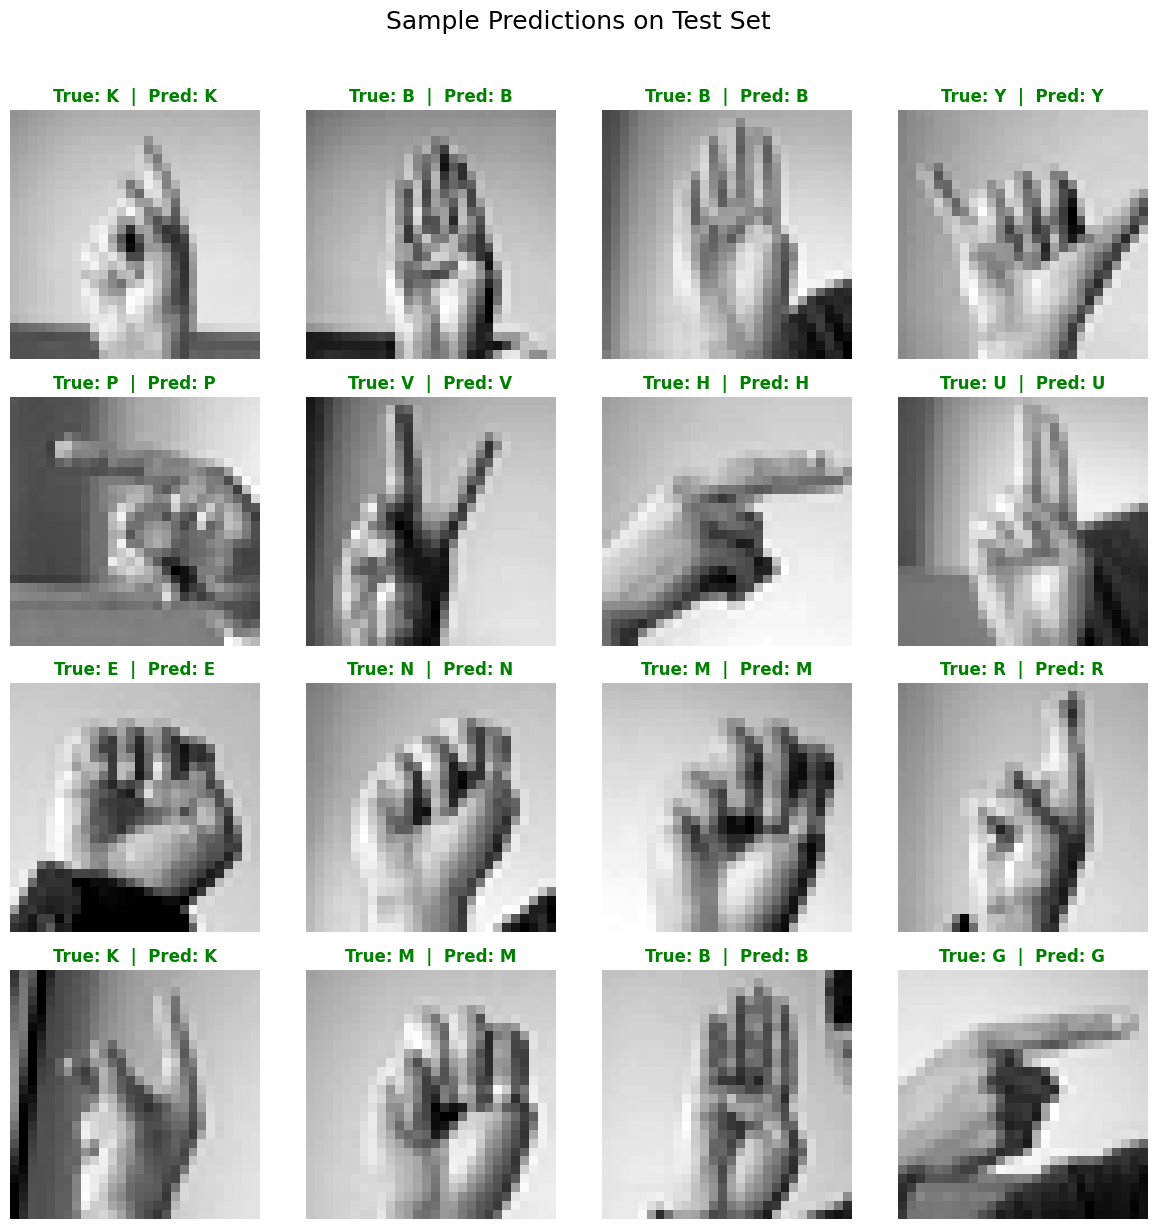

In [16]:
# Sample Predictions – Test Images with true and predicted Labels
num_samples = 16
random_indices = np.random.choice(len(x_test), num_samples, replace=False)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
fig.suptitle('Sample Predictions on Test Set', fontsize=18, y=1.02)

for i, ax in enumerate(axes.flat):
    idx = random_indices[i]
    ax.imshow(np.squeeze(x_test[idx]), cmap='gray')
    true_label = label_lookup[y_true[idx]]
    pred_label = label_lookup[y_pred[idx]]
    correct = y_true[idx] == y_pred[idx]
    color = 'green' if correct else 'red'
    ax.set_title(f'True: {true_label}  |  Pred: {pred_label}',
                 color=color, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()